In [1]:
import pandas as pd
import numpy as np
from netCDF4 import Dataset
import matplotlib
import matplotlib.pyplot as plt
import copy
matplotlib.rc('text', usetex=False)

fs = 33

matplotlib.rc('xtick', labelsize=fs)
matplotlib.rc('ytick', labelsize=fs)
plt.rcParams['axes.titley'] = 1.1

colors = ['#ddcc77', '#999933', '#332288', '#117733', '#44aa99', '#88ccee', '#cc6677', '#882255', '#aa4499', '#dddddd']#, '#ddcc77', '#999933', '#332288', '#117733', '#44aa99', '#88ccee', '#cc6677', '#882255', '#aa4499', '#dddddd']
c_mip = ['#332288', '#aa4499', '#44aa99', '#88ccee','#117733','#ddcc77','#882255','#dddddd','#999933','#882255']

In [2]:
data_dir = 'data/'
plot_dir = 'plots/'

# Load CMCC data

In [3]:
data_exp = pd.read_csv(data_dir+'cmip6-experiments_13_01_2025.csv')
df_exp = pd.DataFrame(data_exp).iloc[:,:]

In [4]:
data_mip = pd.read_csv(data_dir+'cmip6_experiments_MIPs.csv', usecols = [0,1], nrows=270, skiprows=4)#, index_col=0) #index_col is chosen based on usecol subset
df_mip = pd.DataFrame(data_mip).iloc[:,:]

In [5]:
mip_column = df_mip['Activity']
df_expMIP = pd.concat([df_exp,mip_column], axis = 1)

# Sorting, etc. of data

In [6]:
# sorted according to number of downloads
df_expMIP_resort = df_expMIP.sort_values(by=['number_of_downloads'],ascending=False)

In [7]:
# split entries of experiments that are listed with multiple activities
df_expMIP_tmp=df_expMIP.sort_values(by=['Activity'])

df_expMIP_split=df_expMIP_tmp.assign(Activity=df_expMIP.Activity.str.split(',')).explode('Activity').dropna().reset_index(drop=True)
# remove leading space
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' AerChemMIP','Activity']='AerChemMIP'
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' LUMIP','Activity']='LUMIP'
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' CDRMIP','Activity']='CDRMIP'

print(df_expMIP.Activity.unique())
print(df_expMIP_split.Activity.unique)
df_expMIP_split['% nod']=df_expMIP_split['number_of_downloads'] / df_expMIP_split.groupby('Activity')['number_of_downloads'].transform('sum')
df_expMIP_split['% tsGB']=df_expMIP_split['total_size_GB'] / df_expMIP_split.groupby('Activity')['total_size_GB'].transform('sum')

df_split_orig=copy.deepcopy(df_expMIP_split) # without introducing new lines for pie charts

df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d-methane', 'experiment_name'] = 'deglaciation\nglac1d-methane'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d', 'experiment_name'] = 'deglaciation\nglac1d'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-ice6g', 'experiment_name'] = 'deg.\nice6g'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'midpliocene-eoi400', 'experiment_name'] = 'midpliocene\neoi400'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == '1pctco2-cdr', 'experiment_name'] = '1pctco2\ncdr'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'esm-1pct-brch-1000pgc', 'experiment_name'] = 'esm-1pct\nbrch-1000pgc'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'abrupt-2xco2', 'experiment_name'] = 'abrupt\n2xco2'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'amip-4xco2', 'experiment_name'] = 'amip\n4xco2'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'piclim-histaer', 'experiment_name'] = 'piclim\nhistaer'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'piclim-histghg', 'experiment_name'] = 'piclim\nhistghg'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'highressst-future', 'experiment_name'] = 'highressst\nfuture'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'highres-future', 'experiment_name'] = 'highres\nfuture'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'control-1950', 'experiment_name'] = 'control\n1950'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'esm-1pct-brch-2000pgc', 'experiment_name'] = 'esm-1pct\nbrch-2000pgc'

['CMIP' 'ScenarioMIP' 'ScenarioMIP, AerChemMIP' 'HighResMIP' 'DCPP'
 'DAMIP' 'OMIP' 'PMIP' 'LUMIP' 'ISMIP6' 'AerChemMIP' 'PAMIP' 'C4MIP'
 'GMMIP' 'CFMIP' 'GeoMIP' 'LS3MIP' 'FAFMIP' 'C4MIP, CDRMIP'
 'LS3MIP, LUMIP' 'RFMIP, AerChemMIP' 'RFMIP' 'CDRMIP' nan 'VolMIP'
 'Palmod']
<bound method Series.unique of 0      AerChemMIP
1      AerChemMIP
2      AerChemMIP
3      AerChemMIP
4      AerChemMIP
          ...    
267    AerChemMIP
268        VolMIP
269        VolMIP
270        VolMIP
271        VolMIP
Name: Activity, Length: 272, dtype: object>


In [8]:
# split entries of experiments that are listed with multiple activities
df_expMIP_resort_tmp=df_expMIP_resort.sort_values(by=['Activity']) # need to use resorted to keep sorting within an activity by number of downloads
df_expMIP_resort_split=df_expMIP_resort.assign(Activity=df_expMIP_resort.Activity.str.split(',')).explode('Activity').dropna().reset_index(drop=True)
# remove leading space
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' AerChemMIP','Activity']='AerChemMIP'
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' LUMIP','Activity']='LUMIP'
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' CDRMIP','Activity']='CDRMIP'

print(df_expMIP_resort.Activity.unique())
print(df_expMIP_resort_split.Activity.unique)
df_expMIP_resort_split['% nod']=df_expMIP_resort_split['number_of_downloads'] / df_expMIP_resort_split.groupby('Activity')['number_of_downloads'].transform('sum')
df_expMIP_resort_split['% tsGB']=df_expMIP_resort_split['total_size_GB'] / df_expMIP_resort_split.groupby('Activity')['total_size_GB'].transform('sum')

df_resort_split_orig=copy.deepcopy(df_expMIP_resort_split) # without introducing new lines for pie charts

df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d-methane', 'experiment_name'] = 'deglaciation\nglac1d-methane'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d', 'experiment_name'] = 'deglaciation\nglac1d'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-ice6g', 'experiment_name'] = 'deglaciation\nice6g'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'midpliocene-eoi400', 'experiment_name'] = 'midpliocene\neoi400'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == '1pctco2-cdr', 'experiment_name'] = '1pctco2\ncdr'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'esm-1pct-brch-1000pgc', 'experiment_name'] = 'esm-1pct\nbrch-1000pgc'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'abrupt-2xco2', 'experiment_name'] = 'abrupt\n2xco2'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'amip-4xco2', 'experiment_name'] = 'amip\n4xco2'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'piclim-histaer', 'experiment_name'] = 'piclim\nhistaer'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'piclim-histghg', 'experiment_name'] = 'piclim\nhistghg'

['CMIP' 'ScenarioMIP' 'DCPP' 'ScenarioMIP, AerChemMIP' 'HighResMIP'
 'PAMIP' 'DAMIP' 'PMIP' 'ISMIP6' 'LUMIP' 'AerChemMIP' 'C4MIP' 'OMIP'
 'LS3MIP, LUMIP' 'LS3MIP' 'RFMIP, AerChemMIP' 'GeoMIP' 'RFMIP'
 'C4MIP, CDRMIP' 'GMMIP' 'CFMIP' 'FAFMIP' 'VolMIP' 'CDRMIP' nan 'Palmod']
<bound method Series.unique of 0             CMIP
1      ScenarioMIP
2             CMIP
3      ScenarioMIP
4             DCPP
          ...     
267         CDRMIP
268         Palmod
269         Palmod
270         Palmod
271         Palmod
Name: Activity, Length: 272, dtype: object>


In [9]:
labels_mip = df_expMIP_split['Activity'].unique()

In [10]:
dfs_mip= []
dict_mip = {}
for l in labels_mip:

    tmp=df_expMIP_resort_split[df_expMIP_resort_split['Activity']==l]
    tmp2 = tmp[tmp['% nod']>=0.1]
    tmp3 = tmp[tmp['% nod']<0.1]
    n_o=len(tmp3)
    new_row = pd.DataFrame(data = {'experiment_name' : ['others (%d)' % (n_o)],
                                   'number_of_downloads' : [tmp3['number_of_downloads'].sum()], 
                                   'total_size_GB': [tmp3['total_size_GB'].sum()], 
                                   '% nod': [tmp3['% nod'].sum()],
                                   'Activity' : [l]})
    df = pd.concat([tmp2,new_row])
    if l=='PMIP':
        print(tmp2)

    dfs_mip.append(df)
    dict_mip.update({l: np.asarray(df['% nod'].values)})

        experiment_name  number_of_downloads  total_size_GB Activity  \
25          midholocene               533338      100944.93     PMIP   
28              lig127k               412731       80358.84     PMIP   
30             past1000               375417       21527.37     PMIP   
44  midpliocene\neoi400               182235       44595.41     PMIP   

       % nod    % tsGB  
25  0.295213  0.331501  
28  0.228455  0.263897  
30  0.207801  0.070695  
44  0.100871  0.146451  


In [11]:
dfs_mip_size= []
dict_mip_size = {}
for l in labels_mip:
    tmp=df_expMIP_split[df_expMIP_split['Activity']==l]
    tmp2 = tmp[tmp['% tsGB']>=0.1]
    tmp3 = tmp[tmp['% tsGB']<0.1]
    n_o=len(tmp3)
    new_row = pd.DataFrame(data = {'experiment_name' : ['others (%d)' % (n_o)],
                                   'number_of_downloads' : [tmp3['number_of_downloads'].sum()], 
                                   'total_size_GB': [tmp3['total_size_GB'].sum()], '% tsGB': [tmp3['% tsGB'].sum()],
                                   'Activity' : [l]})
    if l=='PMIP':
        print(tmp2)

    df = pd.concat([tmp2,new_row])
    dfs_mip_size.append(df)
    dict_mip_size.update({l: np.asarray(df['% tsGB'].values)})

         experiment_name  number_of_downloads  total_size_GB Activity  \
225                  lgm               139524       36114.90     PMIP   
226  midpliocene\neoi400               182235       44595.41     PMIP   
227              lig127k               412731       80358.84     PMIP   
230          midholocene               533338      100944.93     PMIP   

        % nod    % tsGB  
225  0.077229  0.118601  
226  0.100871  0.146451  
227  0.228455  0.263897  
230  0.295213  0.331501  


# Bar plots with percentual contribution of experiments per MIP

In [12]:
import textwrap
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)

def plotBar(ax,results,exp_names,label_rot=0,xlabel_fs=20,barlabel_fs=10,xticks_fs=20,yticks_fs=20,hideYlabels=False):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = list(results.values())
    data_cs, starts = [],[]
    cmap = plt.get_cmap('YlGnBu')
    category_colors = []
    for d in data:
        tmp=d.cumsum()
        data_cs.append(tmp)
        category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
        starts.append(tmp-d)

#    fig, ax = plt.subplots(figsize=(9.2, 15))
    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,exp_names)):
        rects = ax.barh(l, d, left=start, height=0.5,
                        label=l, color=color)
        ax.tick_params(axis="y",labelsize=yticks_fs, length=5, width=1, color ='black', direction='out')
        text_color = 'k'
        ax.set_xticks(np.arange(0,1.1,0.1))
        if hideYlabels==True:
            ax.set_yticklabels('')
        ax.set_xticklabels(range(0,110,10),fontsize=xticks_fs)
        ax.set_xlabel("percentage of number of downloads [%]",fontsize=xlabel_fs)
        ax.tick_params(axis='x', length=5, width=1, color ='black', direction='out')
        ax.bar_label(rects, labels=df['experiment_name'].values, label_type='center', color=text_color,rotation=label_rot,fontsize=barlabel_fs)
    #ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
    #          loc='lower left', fontsize='small')

    wrap_labels(ax,10)

    return fig, ax

In [13]:
def plotBar_size(ax,results,exp_names,label_rot=0,xlabel_fs=20,barlabel_fs=10,xticks_fs=20,yticks_fs=20,hideYlabels=False):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = list(results.values())
    data_cs, starts = [],[]
    cmap = plt.get_cmap('YlGnBu')
    category_colors = []
    for d in data:
        tmp=d.cumsum()
        data_cs.append(tmp)
        category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
        starts.append(tmp-d)

    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,exp_names)):
        rects = ax.barh(l, d, left=start, height=0.5,
                        label=l, color=color)
        ax.tick_params(axis="y",labelsize=yticks_fs, length=5, width=1, color ='black', direction='out')
        text_color = 'k'
        ax.set_xticks(np.arange(0,1.1,0.1))
        if hideYlabels==True:
            ax.set_yticklabels('')
        ax.set_xticklabels(range(0,110,10),fontsize=xticks_fs)
        ax.set_xlabel("percentage of size of downloads [%]",fontsize=xlabel_fs)
        ax.tick_params(axis='x', length=5, width=1, color ='black', direction='out')
        ax.bar_label(rects, labels=df['experiment_name'].values, label_type='center', color=text_color,rotation=label_rot,fontsize=barlabel_fs)
    #ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
    #          loc='lower left', fontsize='small')

    wrap_labels(ax,10)

    return fig, ax


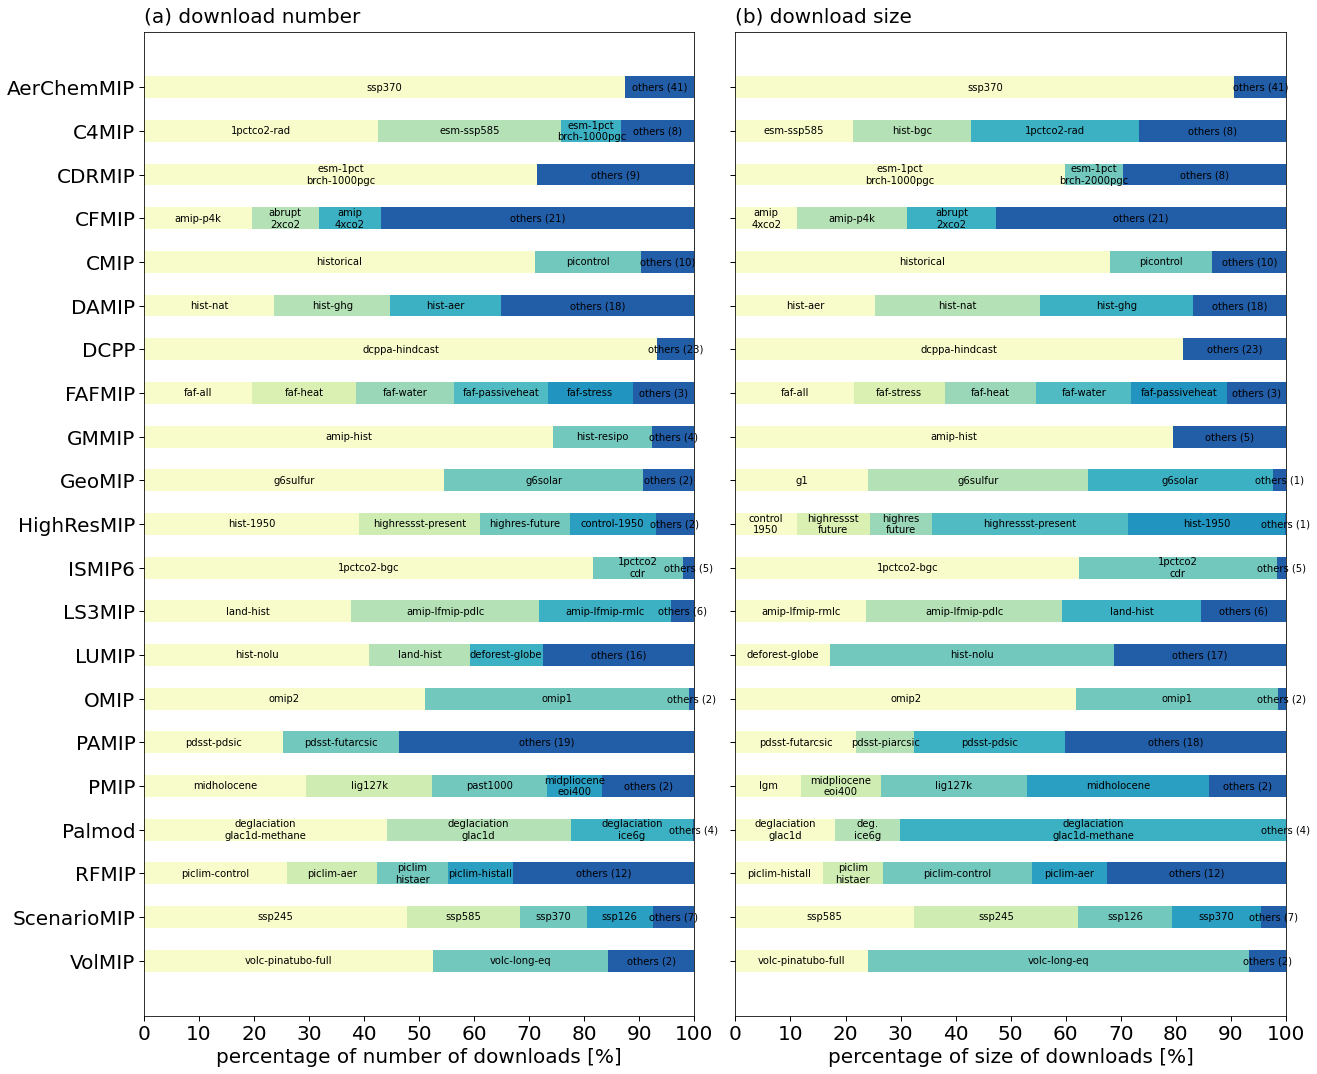

In [14]:
fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(18.4, 15))
#figname=plot_dir+'exp_per_mip_barh_download_size'
plotBar(ax[0],dict_mip,dfs_mip,label_rot=0)
plotBar_size(ax[1],dict_mip_size,dfs_mip_size,hideYlabels=True)
#fig.savefig(figname+'.png', bbox_inches='tight',transparent=False,facecolor='white')
#fig.savefig(figname+'.pdf',format='pdf', bbox_inches='tight',transparent=False)
ax[0].text(0., 1.01, '(a) download number', transform = ax[0].transAxes,fontsize=20)
ax[1].text(0., 1.01, '(b) download size', transform = ax[1].transAxes,fontsize=20)
plt.tight_layout()

figname=plot_dir+'fig_exp_per_mip'
fig.savefig(figname+'.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(figname+'.pdf',format='pdf', bbox_inches='tight',transparent=False)

plt.show()

# Bar plots with downloads per MIP

In [15]:
mip_sum = []
mip_nDown = []
mip_nSize = []
for n in labels_mip:
    tmp=df_expMIP.dropna()[df_expMIP.dropna()['Activity'].str.contains(n)].sum()
    tmp['Activity']=n
    mip_sum.append(tmp)
    mip_nDown.append(tmp['number_of_downloads'])
    mip_nSize.append(tmp['total_size_GB'])


In [16]:
df_mip_cmp = pd.DataFrame(
    {'mip_name': labels_mip,
     'number_of_downloads': mip_nDown,
     'total_size_TB': mip_nSize
    })

In [17]:
df_mip_cmp_resort=df_mip_cmp.sort_values(by=['number_of_downloads'],ascending=False)


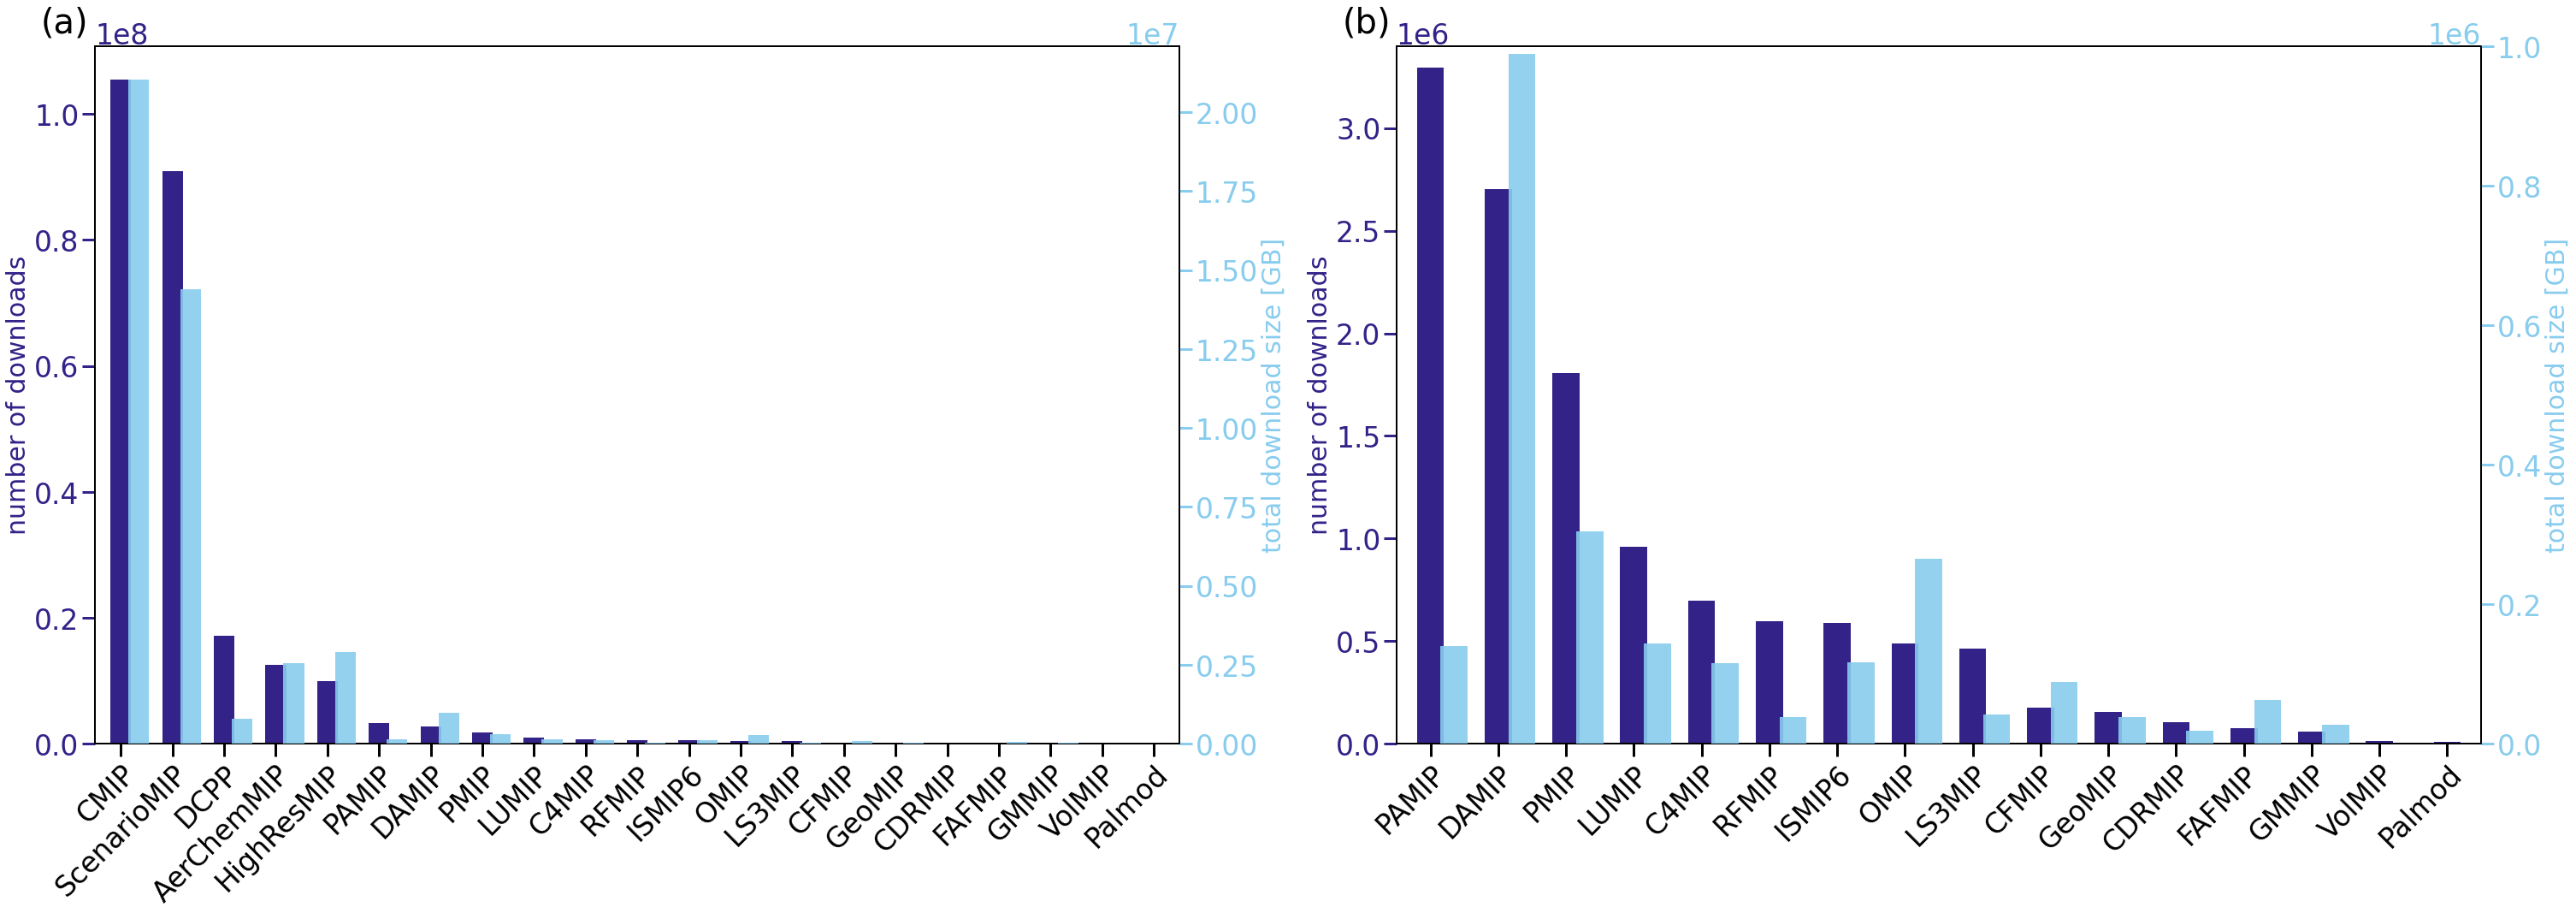

In [18]:
matplotlib.rcParams['figure.figsize'] = (50.0, 15.0)
fig, ax = plt.subplots(nrows=1,ncols=2)

ax[0].bar(range(0,len(labels_mip)*2,2),df_mip_cmp_resort['number_of_downloads'],color='#332288')
twin = ax[0].twinx()
twin.bar(np.asarray(range(0,len(labels_mip)*2,2))+0.7,df_mip_cmp_resort['total_size_TB'],color='#88ccee',alpha=0.9)

#ax[0].set_xticklabels(['']*len(labels_mip))#, rotation=45, ha='right')
ax[0].set_xticks(range(0,len(labels_mip)*2,2))
ax[0].set_xticklabels(df_mip_cmp_resort['mip_name'],rotation=45, ha='right', rotation_mode='anchor')
#ax[0].grid()
ax[0].set_xlim(-1,41)
#ax[0].set_title('Downloads per MIP',y=1.02,fontsize=30)
ax[0].set_ylabel('number of downloads',fontsize=30,color='#332288')
ax[0].tick_params(axis='y', colors='#332288', width=3, length=15)
ax[0].tick_params(axis='x', width=3, length=15)
twin.set_ylabel('total download size [GB]',fontsize=30,color='#88ccee')
twin.tick_params(axis='y', colors='#88ccee', width=3, length=15)
#twin.set_ylim(0,0.4*10**7)
ax[0].spines['top'].set_linewidth(2)
ax[0].spines['left'].set_linewidth(2)
ax[0].spines['right'].set_linewidth(2)
ax[0].spines['bottom'].set_linewidth(2)
ax[0].text(-0.05, 1.02,'(a)', fontsize=40,zorder=15, transform = ax[0].transAxes)

# Zoom panel for shorter ones
start_idx = 5
ax[1].bar(range(0,len(labels_mip[start_idx:])*2,2),df_mip_cmp_resort[start_idx:]['number_of_downloads'],color='#332288')
twin = ax[1].twinx()
twin.bar(np.asarray(range(0,len(labels_mip[start_idx:])*2,2))+0.7,df_mip_cmp_resort[start_idx:]['total_size_TB'],color='#88ccee',alpha=0.9)

#ax[1].set_xticklabels(['']*len(labels_mip))#, rotation=45, ha='right')
ax[1].set_xticks(range(0,len(labels_mip[start_idx:])*2,2))
ax[1].set_xticklabels(df_mip_cmp_resort[start_idx:]['mip_name'],rotation=45, ha='right', rotation_mode='anchor')
#ax[1].grid()
ax[1].set_ylim(0,0.34*10**7)
ax[1].set_xlim(-1,31)
#ax[1].set_title('Downloads per MIP',y=1.02,fontsize=30)
ax[1].set_ylabel('number of downloads',fontsize=30,color='#332288')
ax[1].tick_params(axis='y', colors='#332288', width=3, length=15)
ax[1].tick_params(axis='x', width=3, length=15)
twin.set_ylabel('total download size [GB]',fontsize=30,color='#88ccee')
twin.tick_params(axis='y', colors='#88ccee', width=3, length=15)
twin.set_ylim(0,1.0*10**6)
ax[1].spines['top'].set_linewidth(2)
ax[1].spines['left'].set_linewidth(2)
ax[1].spines['right'].set_linewidth(2)
ax[1].spines['bottom'].set_linewidth(2)
ax[1].text(-0.05, 1.02,'(b)', fontsize=40,zorder=15, transform = ax[1].transAxes)

plt.subplots_adjust(wspace=0.2)

fig.savefig(plot_dir+'fig_mipDownloads.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(plot_dir+'fig_mipDownloads.pdf',format='pdf', bbox_inches='tight',transparent=False)